In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from pathlib import Path
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


In [2]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [4]:
DATA_DIR = Path("../Data/processed")

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

In [5]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

In [6]:
train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=val_transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=val_transform
)

In [7]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

NUM_CLASSES = len(train_dataset.classes)

print("Classes:", NUM_CLASSES)
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Classes: 90
Train: 4320
Validation: 540
Test: 540


In [8]:
class AnimalCNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        x = self.features(x)

        x = self.pool(x)

        x = self.classifier(x)

        return x

In [9]:
model = AnimalCNN(NUM_CLASSES)

model = model.to(DEVICE)

print(model)

AnimalCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

In [10]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 412506
Trainable parameters: 412506


In [15]:
criterion = nn.CrossEntropyLoss()

In [16]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
    
)

In [17]:
images, labels = next(iter(train_loader))

images = images.to(DEVICE)
labels = labels.to(DEVICE)

outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 90])


In [18]:
loss = criterion(outputs, labels)

print("Initial loss:", loss.item())

Initial loss: 4.61435079574585


In [19]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [20]:
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [21]:
train_loss, train_acc = train_one_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    DEVICE
)

val_loss, val_acc = validate(
    model,
    val_loader,
    criterion,
    DEVICE
)

print(f"Train Loss: {train_loss:.4f}")
print(f"Train Accuracy: {train_acc:.4f}")

print(f"Val Loss: {val_loss:.4f}")
print(f"Val Accuracy: {val_acc:.4f}")

Train Loss: 4.3352
Train Accuracy: 0.0366
Val Loss: 4.1330
Val Accuracy: 0.0704


In [22]:
model = AnimalCNN(NUM_CLASSES).to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [23]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

In [24]:
NUM_EPOCHS = 15

best_val_loss = float("inf")

patience = 4
epochs_without_improvement = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

In [25]:
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

In [27]:
print("Model device:", next(model.parameters()).device)

Model device: cuda:0


In [28]:
images, labels = next(iter(train_loader))

images = images.to(DEVICE)
labels = labels.to(DEVICE)

print("Images:", images.device)
print("Labels:", labels.device)
print("Model:", next(model.parameters()).device)

Images: cuda:0
Labels: cuda:0
Model: cuda:0


In [29]:
for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch [{epoch + 1}/{NUM_EPOCHS}]")

    # -------------------------
    # Training
    # -------------------------
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    # -------------------------
    # Validation
    # -------------------------
    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    # -------------------------
    # Scheduler
    # -------------------------
    scheduler.step(val_loss)

    # Store history
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    # Current learning rate
    current_lr = optimizer.param_groups[0]["lr"]

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc : {train_acc:.4f}")

    print(f"Val Loss  : {val_loss:.4f}")
    print(f"Val Acc   : {val_acc:.4f}")

    print(f"Learning Rate: {current_lr:.6f}")

    # -------------------------
    # Save best model
    # -------------------------
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        epochs_without_improvement = 0

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "class_to_idx": train_dataset.class_to_idx,
                "classes": train_dataset.classes,
                "val_loss": val_loss,
                "val_accuracy": val_acc
            },
            MODEL_DIR / "baseline_cnn_best.pth"
        )

        print("✓ Best model saved!")

    else:

        epochs_without_improvement += 1

        print(
            f"No improvement: "
            f"{epochs_without_improvement}/{patience}"
        )

    # -------------------------
    # Early stopping
    # -------------------------
    if epochs_without_improvement >= patience:

        print("\nEarly stopping triggered.")

        break


Epoch [1/15]
Train Loss: 3.9485
Train Acc : 0.0847
Val Loss  : 3.9208
Val Acc   : 0.1093
Learning Rate: 0.001000
✓ Best model saved!

Epoch [2/15]
Train Loss: 3.8422
Train Acc : 0.0956
Val Loss  : 3.8092
Val Acc   : 0.1444
Learning Rate: 0.001000
✓ Best model saved!

Epoch [3/15]
Train Loss: 3.7537
Train Acc : 0.1187
Val Loss  : 3.7896
Val Acc   : 0.1352
Learning Rate: 0.001000
✓ Best model saved!

Epoch [4/15]
Train Loss: 3.6811
Train Acc : 0.1275
Val Loss  : 3.6659
Val Acc   : 0.1648
Learning Rate: 0.001000
✓ Best model saved!

Epoch [5/15]
Train Loss: 3.6389
Train Acc : 0.1313
Val Loss  : 3.5810
Val Acc   : 0.1796
Learning Rate: 0.001000
✓ Best model saved!

Epoch [6/15]
Train Loss: 3.5210
Train Acc : 0.1597
Val Loss  : 3.6747
Val Acc   : 0.1593
Learning Rate: 0.001000
No improvement: 1/4

Epoch [7/15]
Train Loss: 3.4967
Train Acc : 0.1574
Val Loss  : 3.6241
Val Acc   : 0.1833
Learning Rate: 0.001000
No improvement: 2/4

Epoch [8/15]
Train Loss: 3.4160
Train Acc : 0.1764
Val Loss  

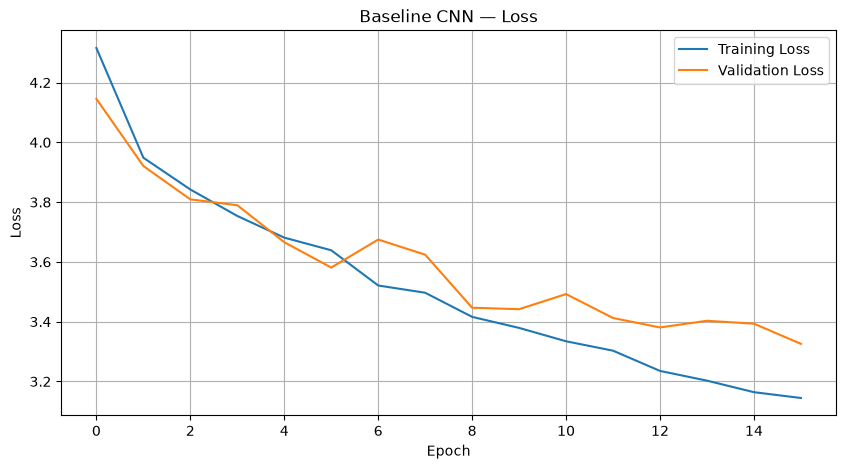

In [32]:
import matplotlib.pyplot as plt   
plt.figure(figsize=(10, 5))

plt.plot(
    history["train_loss"],
    label="Training Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN — Loss")

plt.legend()
plt.grid()

plt.show()

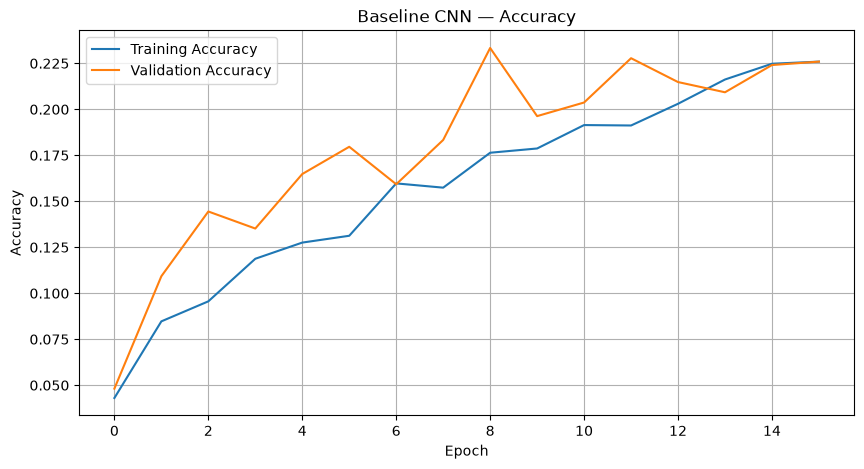

In [33]:
plt.figure(figsize=(10, 5))

plt.plot(
    history["train_acc"],
    label="Training Accuracy"
)

plt.plot(
    history["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN — Accuracy")

plt.legend()
plt.grid()

plt.show()

In [34]:
best_val_acc = max(history["val_acc"])

print(
    f"Best validation accuracy: "
    f"{best_val_acc * 100:.2f}%"
)

Best validation accuracy: 23.33%


In [35]:
checkpoint = torch.load(
    MODEL_DIR / "baseline_cnn_best.pth",
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.to(DEVICE)

print("Best baseline model loaded.")
print("Validation loss:", checkpoint["val_loss"])
print("Validation accuracy:", checkpoint["val_accuracy"])

Best baseline model loaded.
Validation loss: 3.3257095548841686
Validation accuracy: 0.22592592592592592


In [36]:
test_loss, test_acc = validate(
    model,
    test_loader,
    criterion,
    DEVICE
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc * 100:.2f}%")

Test Loss: 3.3028
Test Accuracy: 20.93%


In [37]:
from sklearn.metrics import classification_report
import numpy as np

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=test_dataset.classes,
        zero_division=0
    )
)

                precision    recall  f1-score   support

      antelope       1.00      0.17      0.29         6
        badger       0.00      0.00      0.00         6
           bat       1.00      0.17      0.29         6
          bear       0.14      0.17      0.15         6
           bee       0.14      0.17      0.15         6
        beetle       0.33      0.33      0.33         6
         bison       0.00      0.00      0.00         6
          boar       0.25      0.17      0.20         6
     butterfly       1.00      0.17      0.29         6
           cat       0.00      0.00      0.00         6
   caterpillar       0.20      0.17      0.18         6
    chimpanzee       0.00      0.00      0.00         6
     cockroach       0.43      0.50      0.46         6
           cow       0.00      0.00      0.00         6
        coyote       0.17      0.17      0.17         6
          crab       1.00      0.17      0.29         6
          crow       0.40      0.33      0.36  

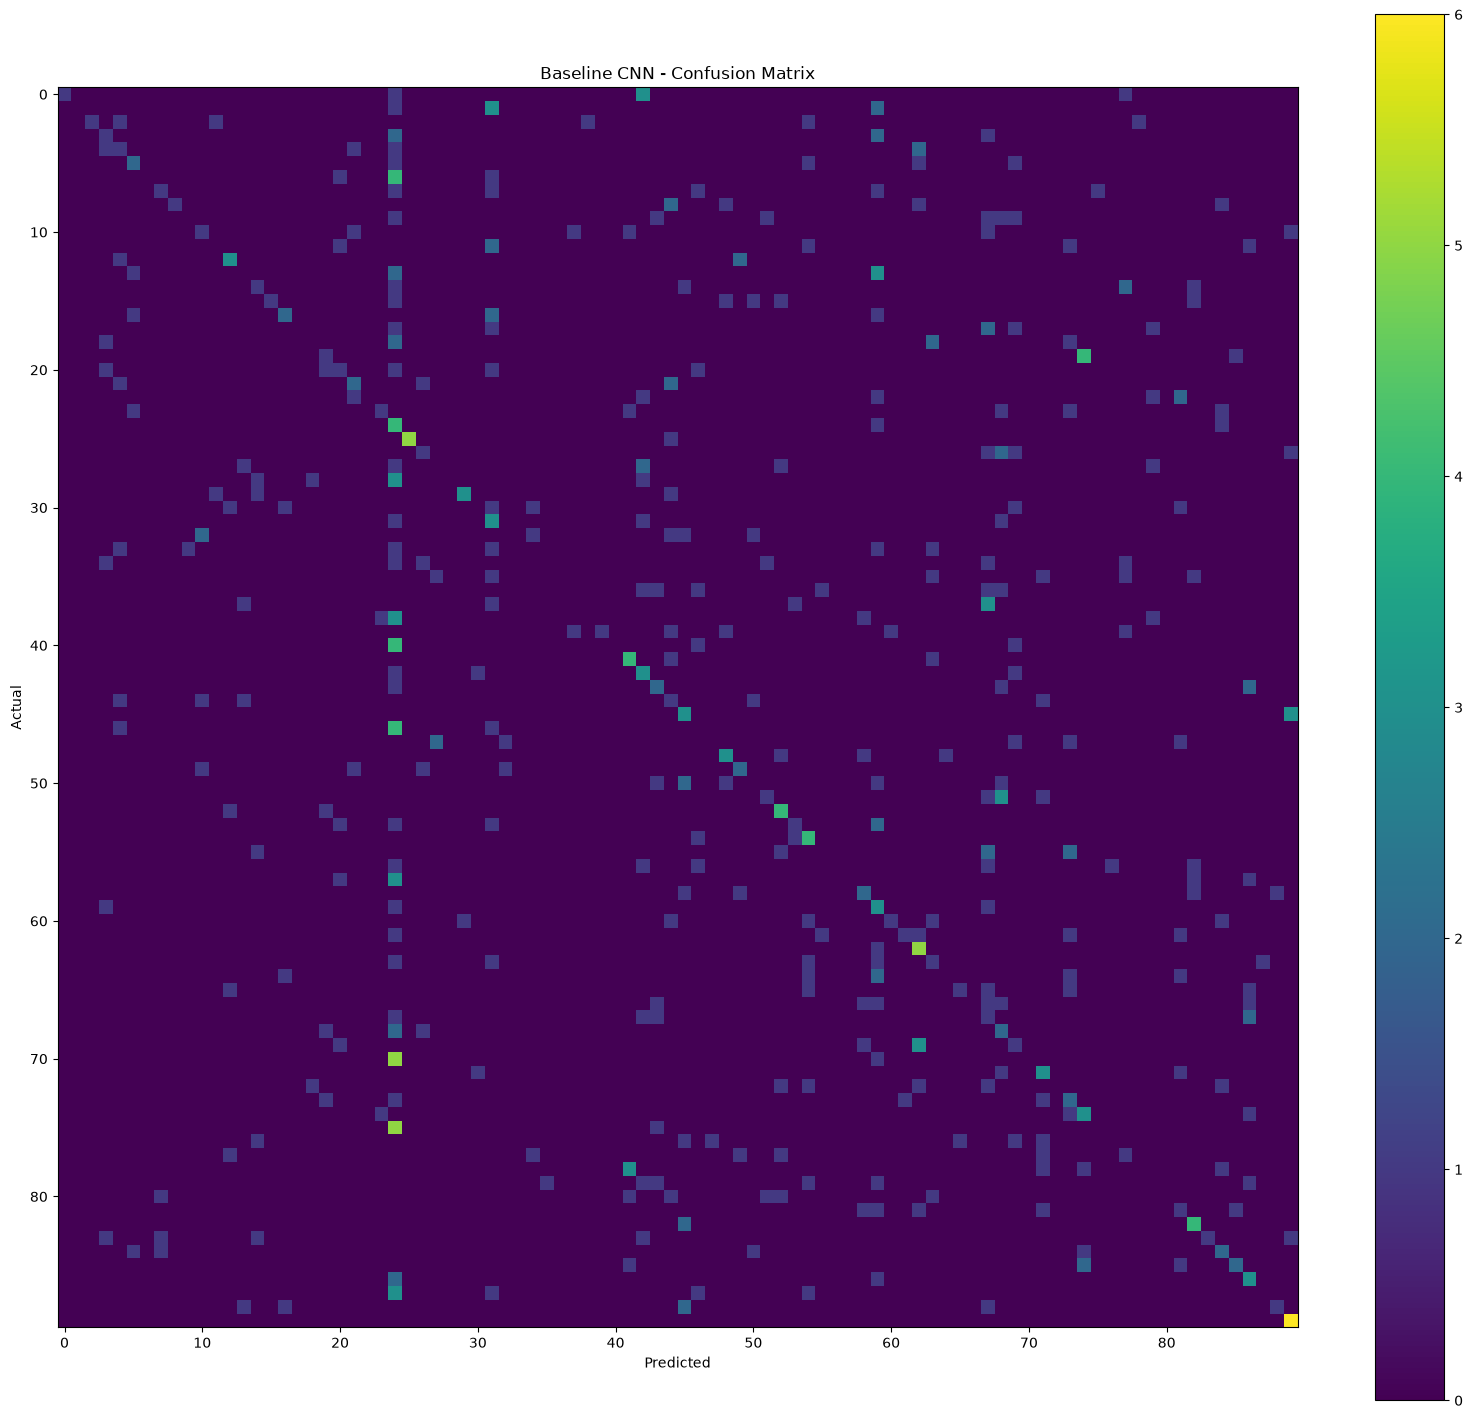

: 

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(20, 18))

plt.imshow(cm)

plt.title("Baseline CNN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

plt.show()